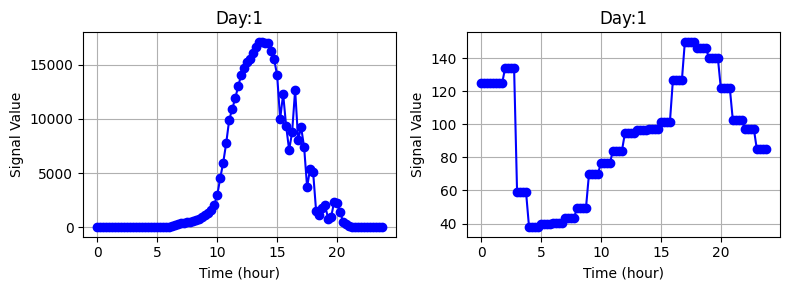

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from modules.solar import PVdata
from modules.economy import ElecPrice

pv_data_path = './data/timeseries-slimpark-2022.csv'
price_data_path='./data/day_ahead_prices_2022.csv'
PV_panel = PVdata(pv_data_path)
elec_price = ElecPrice(price_data_path)

expanded_pv = np.hstack([np.zeros(1,), PV_panel.day_data])
expanded_price = np.hstack([np.zeros(1,), elec_price.day_price_data])

# Create time axis for original and expanded data
time_axis_original = np.arange(0, 24, 1)
time_axis_expanded = np.arange(0, 24, 0.25)

# Plot the original and expanded data in subplots
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1)
plt.plot(time_axis_expanded, expanded_pv[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)

plt.subplot(1,2,2)
# plt.plot(time_axis_original.astype(str), price_day[1:], marker='o', linestyle='-', color='g', label='Original Data (1 hour)')
plt.plot(time_axis_expanded, expanded_price[1:], marker='o', linestyle='-', color='b', label='Expanded Data (15 minute)')
plt.xlabel('Time (hour)')
plt.ylabel('Signal Value')
plt.title(f"Day:{PV_panel.day_num}")
plt.grid(True)
plt.tight_layout()
plt.show()


Total number of profiles: 2920


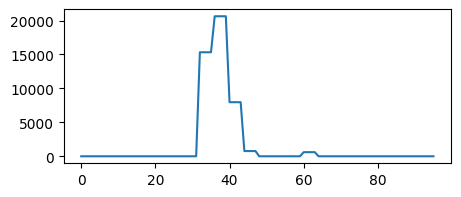

In [2]:
import pandas as pd
import numpy as np

# Load and preprocess data
df = pd.read_csv('data/power_and_active_sessions_cp_UT.csv')
df['date'] = pd.to_datetime(df['times']).dt.date

# Group by date
grouped = df.groupby('date')

# Initialize storage dictionaries
evse_cols = ['evse_1_wh', 'evse_2_wh', 'evse_3_wh', 'evse_4_wh']
evse_data = {col: [] for col in evse_cols}
power_profiles = []

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in evse_cols:
            evse_data[col].append(group[col].to_numpy())
        power_profiles.append(group['power'].to_numpy())

# Convert lists to numpy arrays
for col in evse_cols:
    evse_data[col] = np.array(evse_data[col])
    evse_data[col] = np.where(evse_data[col] < 10, 0, evse_data[col])

power_profiles = np.array(power_profiles)
power_profiles = np.where(power_profiles < 10, 0, power_profiles)

# Optional: unpack if you want the original variable names
evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh = (evse_data[col] for col in evse_cols)

all_profiles = np.concatenate((evse_1_wh, evse_2_wh, evse_3_wh, evse_4_wh), axis=0)
print(f"Total number of profiles: {len(all_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_profiles[12])

Total number of profiles: 730


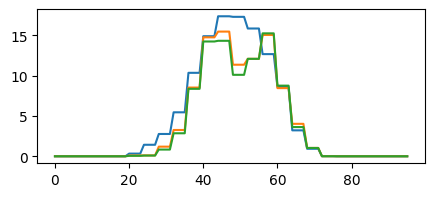

In [3]:
# Initialize storage dictionaries
pv_cols = ['pv_wh', 'pv_forecast_day_ahead_wh', 'pv_forecast_intraday_wh']
pv_data = {col: [] for col in pv_cols}

# Iterate over each day's group
for date, group in grouped:
    if len(group) == 96:
        for col in pv_cols:
            pv_data[col].append(group[col].to_numpy())

# Convert lists to numpy arrays
for col in pv_data:
    pv_data[col] = np.array(pv_data[col])
    pv_data[col] = np.where(pv_data[col] < 0, pv_data[col], 0)

# Optional: unpack if you want the original variable names
pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh = (pv_data[col] for col in pv_cols)

all_pv_profiles = -np.stack((pv_wh, pv_forecast_day_ahead_wh, pv_forecast_intraday_wh), axis=-1)
print(f"Total number of profiles: {len(all_pv_profiles)}")

plt.figure(figsize=(5, 2))
plt.plot(all_pv_profiles[100]/1000)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from sklearn.cluster import KMeans
import numpy as np

class OnlineGMM:
    def __init__(self, num_components=2, buffer_size=200, lr=0.05):
        """Initialize the Online GMM with given parameters."""
        self.K = num_components
        self.buffer = deque(maxlen=buffer_size)
        
        # GMM parameters as PyTorch parameters
        self.means = nn.Parameter(torch.randn(self.K, 1))
        self.log_vars = nn.Parameter(torch.zeros(self.K, 1))
        self.logits = nn.Parameter(torch.zeros(self.K))
        
        # Optimizer
        self.optimizer = optim.Adam([self.means, self.log_vars, self.logits], lr=lr)

    def initialize_with_kmeans(self):
        """Initialize GMM means using KMeans on the buffer."""
        if len(self.buffer) < self.K:
            print("Not enough data to initialize with KMeans.")
            return
        
        data = np.array(self.buffer).reshape(-1, 1)
        kmeans = KMeans(n_clusters=self.K, n_init='auto').fit(data)
        centers = kmeans.cluster_centers_
        # Update the means with the KMeans centers
        with torch.no_grad():
            self.means.copy_(torch.tensor(centers, dtype=torch.float32))

    def gaussian_pdf(self, x, mu, log_var):
        """Compute the Gaussian probability density function."""
        var = torch.exp(log_var)
        return torch.exp(-0.5 * (x - mu)**2 / var) / torch.sqrt(2 * torch.pi * var)

    def update_model(self):
        """Perform one gradient update with the current buffer."""
        # Convert buffer to tensor
        x = torch.tensor(list(self.buffer), dtype=torch.float32).unsqueeze(1)
        
        # Gradient step
        self.optimizer.zero_grad()
        weights = torch.softmax(self.logits, dim=0)
        probs = torch.stack([w * self.gaussian_pdf(x, mu, lv) 
                             for w, mu, lv in zip(weights, self.means, self.log_vars)], dim=0)
        total_prob = torch.sum(probs, dim=0)
        nll = -torch.sum(torch.log(total_prob + 1e-8)) / len(x)
        nll.backward()
        self.optimizer.step()
        return nll.item()
    
    def sample(self, num_samples=1):
        """Sample from the GMM."""
        with torch.no_grad():
            weights = torch.softmax(self.logits, dim=0)
            components = torch.multinomial(weights, num_samples, replacement=True)
            samples = torch.normal(self.means[components], torch.exp(0.5 * self.log_vars[components]))
            return samples.numpy().flatten()

c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\HeydarianArdakaniA\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


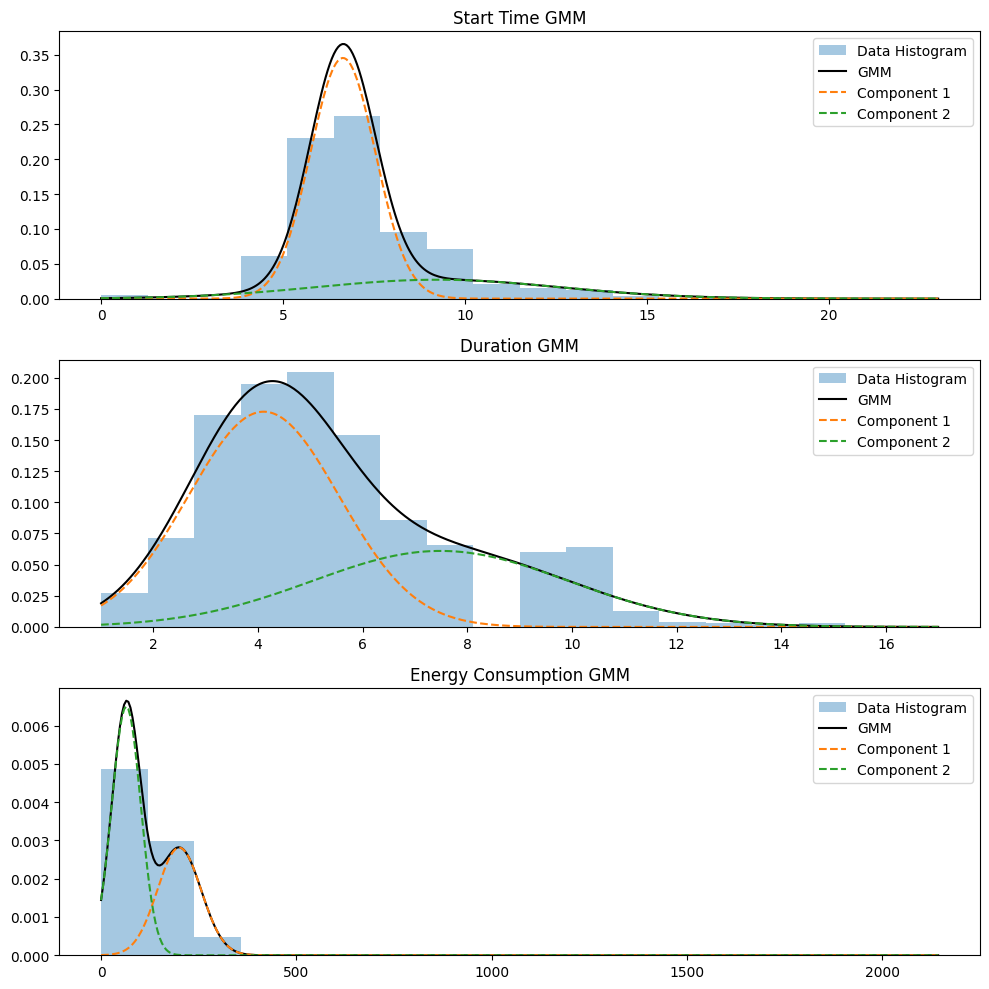

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Assume all_profiles is defined
start_times, durations, energy_consumptions = [], [], []

# Extract features from all_profiles
for prof_id in np.unique(np.where(all_profiles > 10)[0]):
    profile = all_profiles[prof_id]
    active_indices = np.where(profile > 0)[0]
    if len(active_indices) == 0:
        continue
    start = active_indices[0] / 4
    duration = len(active_indices) / 4
    energy = profile[active_indices].sum()/1000
    start_times.append(start)
    durations.append(duration)
    energy_consumptions.append(energy)

# Function to fit an OnlineGMM and return components for plotting
def fit_gmm(data):
    gmm = OnlineGMM(num_components=2, buffer_size=2000, lr=0.05)
    data = np.array(data)

    for point in data:
        gmm.buffer.append(point)
        if len(gmm.buffer) < 20:
            continue
        elif len(gmm.buffer) == 20:
            gmm.initialize_with_kmeans()
        else:
            gmm.update_model()
    
    return gmm, data

# Fit GMMs and keep data as well
gmm_results = {
    "Start Time": fit_gmm(start_times),
    "Duration": fit_gmm(durations),
    "Energy Consumption": fit_gmm(energy_consumptions)
}

# Plotting in 3 subplots with appropriate ranges
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for ax, (title, (gmm, data)) in zip(axes, gmm_results.items()):
    x_vals = torch.linspace(min(data), max(data), 400).unsqueeze(1)
    weights = torch.softmax(gmm.logits, dim=0)
    components = [w * gmm.gaussian_pdf(x_vals, mu, lv) for w, mu, lv in zip(weights, gmm.means, gmm.log_vars)]
    mixture = torch.sum(torch.stack(components), dim=0)

    ax.hist(data, bins=18, density=True, alpha=0.4, label='Data Histogram')
    ax.plot(x_vals.detach(), mixture.detach(), color='black', label='GMM')
    for i, comp in enumerate(components):
        ax.plot(x_vals.detach(), comp.detach(), '--', label=f'Component {i+1}')
    ax.set_title(f'{title} GMM')
    ax.legend()

plt.tight_layout()
plt.show()


In [6]:
ev_data = torch.tensor(np.stack([start_times, durations, energy_consumptions], axis=1))

In [7]:
import torch.nn.functional as F

class MultivariateMDN(nn.Module):
    def __init__(self, n_components=3, output_dim=3):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim
        hidden_dim = 64

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),  # you can use input=0 if unconditional
            nn.ReLU(),
        )

        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)  # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)  # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        # target shape: (B, D)
        target = target.unsqueeze(1)  # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * torch.pi)**0.5)
        prob = prob.prod(dim=-1)  # Multiply across dimensions to get joint
        weighted_prob = pi * prob
        return torch.log(weighted_prob.sum(dim=-1) + 1e-8)

    def sample(self, batch_size=1):
        pi, mu, sigma = self.forward(torch.zeros((batch_size, 1)))
        dist = torch.distributions.Categorical(pi)
        idx = dist.sample()  # (B,)
        mu_chosen = mu[torch.arange(batch_size), idx]      # (B, D)
        sigma_chosen = sigma[torch.arange(batch_size), idx]
        eps = torch.randn_like(mu_chosen)
        return mu_chosen + sigma_chosen * eps


model = MultivariateMDN(n_components=3, output_dim=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for epoch in range(1000):
    batch = ev_data  # shape: (B, 3)
    target = batch

    pi, mu, sigma = model(torch.rand((batch.shape[0], 1)))  # unconditional
    logp = model.log_prob(target, pi, mu, sigma)
    loss = -logp.mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")


Epoch 0, loss = 18.4001
Epoch 100, loss = 18.3935
Epoch 200, loss = 18.3907
Epoch 300, loss = 18.4028
Epoch 400, loss = 18.4051
Epoch 500, loss = 18.3867
Epoch 600, loss = 18.3942
Epoch 700, loss = 18.3902
Epoch 800, loss = 18.3971
Epoch 900, loss = 18.3896


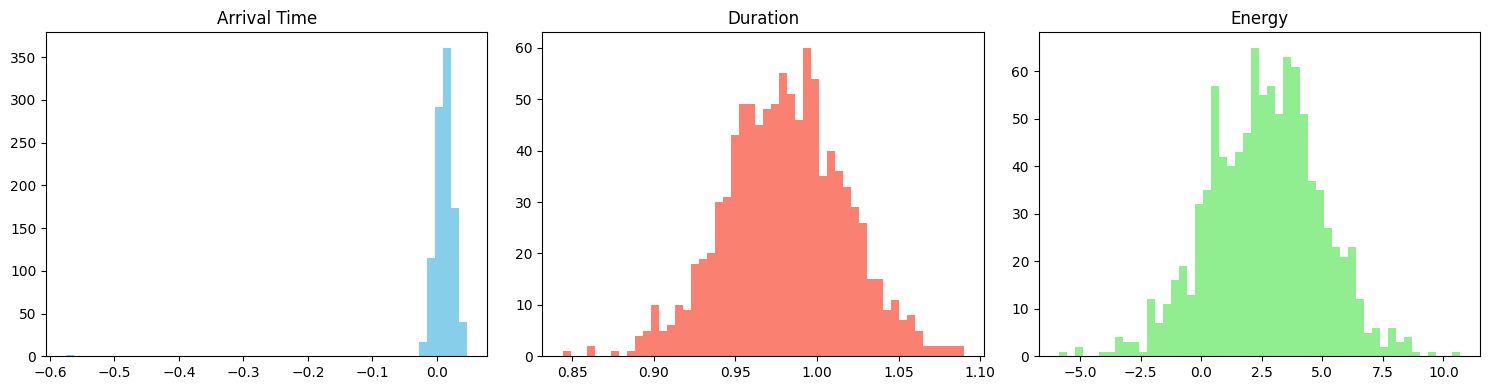

In [8]:
samples = model.sample(batch_size=1000)  # shape: (1000, 3)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(arrival_samples.cpu().detach().numpy(), bins=50, color='skyblue')
axes[0].set_title('Arrival Time')

axes[1].hist(duration_samples.cpu().detach().numpy(), bins=50, color='salmon')
axes[1].set_title('Duration')

axes[2].hist(energy_samples.cpu().detach().numpy(), bins=50, color='lightgreen')
axes[2].set_title('Energy')

plt.tight_layout()
plt.show()


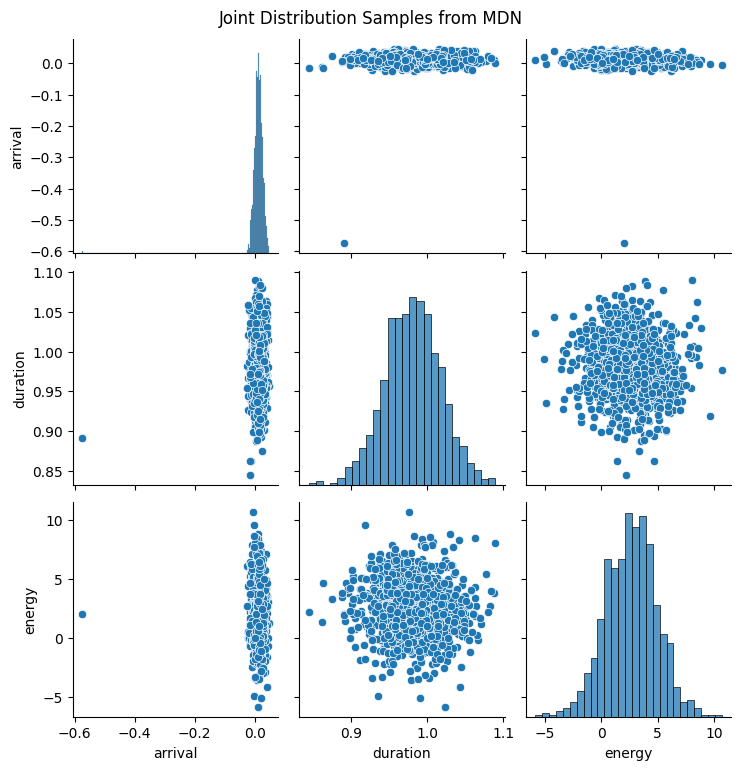

In [9]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame({
    "arrival": arrival_samples.cpu().detach().numpy(),
    "duration": duration_samples.cpu().detach().numpy(),
    "energy": energy_samples.cpu().detach().numpy()
})

sns.pairplot(df)
plt.suptitle("Joint Distribution Samples from MDN", y=1.02)
plt.show()


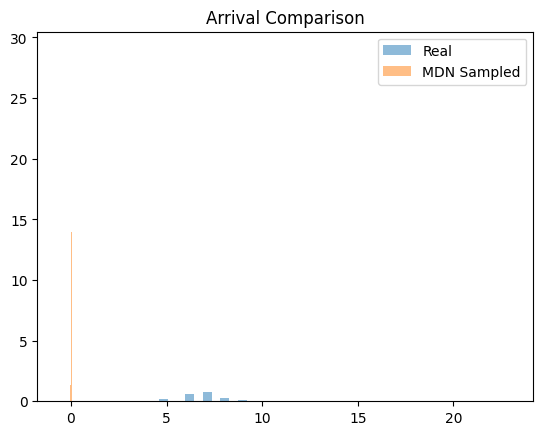

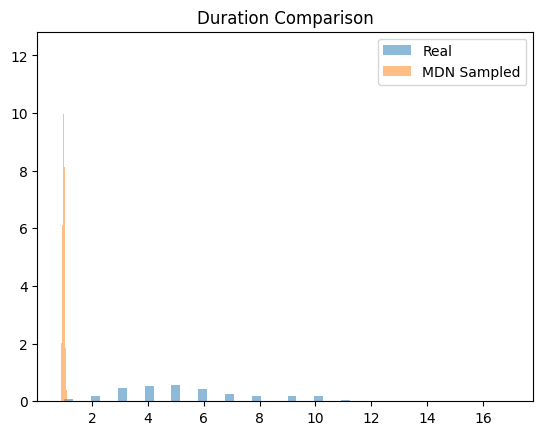

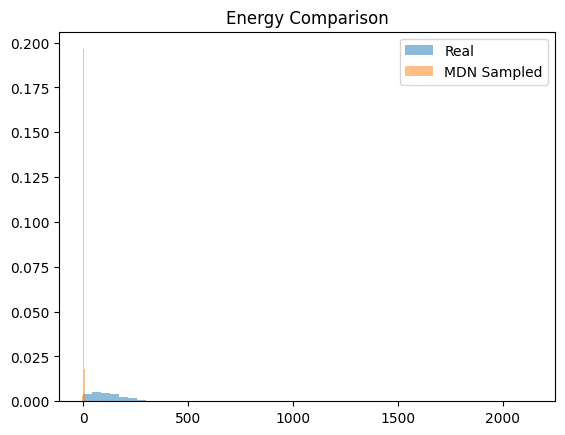

In [10]:
real_df = pd.DataFrame(ev_data, columns=["arrival", "duration", "energy"])
fake_df = pd.DataFrame(samples.cpu().detach().numpy(), columns=["arrival", "duration", "energy"])

# Overlay histograms
for col in ["arrival", "duration", "energy"]:
    plt.hist(real_df[col], bins=50, alpha=0.5, label='Real', density=True)
    plt.hist(fake_df[col], bins=50, alpha=0.5, label='MDN Sampled', density=True)
    plt.title(f"{col.capitalize()} Comparison")
    plt.legend()
    plt.show()


In [13]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

class MDN(nn.Module):
    def __init__(self, input_dim, output_dim, n_components=3, hidden_dim=64):
        super().__init__()
        self.n_components = n_components
        self.output_dim = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.pi = nn.Linear(hidden_dim, n_components)
        self.mu = nn.Linear(hidden_dim, n_components * output_dim)
        self.sigma = nn.Linear(hidden_dim, n_components * output_dim)

    def forward(self, x):
        h = self.net(x)
        pi = F.softmax(self.pi(h), dim=-1)                                     # (B, K)
        mu = self.mu(h).view(-1, self.n_components, self.output_dim)           # (B, K, D)
        sigma = torch.exp(self.sigma(h)).view(-1, self.n_components, self.output_dim) + 1e-6
        return pi, mu, sigma

    def log_prob(self, target, pi, mu, sigma):
        target = target.unsqueeze(1)                                           # (B, 1, D)
        prob = torch.exp(-0.5 * ((target - mu) / sigma)**2) / (sigma * (2 * np.pi)**0.5)
        prob = prob.prod(dim=-1)                                               # (B, K)
        weighted = pi * prob
        return torch.log(weighted.sum(dim=-1) + 1e-8)                           # (B,)

    def sample(self, pi, mu, sigma):
        batch_size = pi.size(0)
        cat = torch.distributions.Categorical(pi)
        indices = cat.sample()                                                 # (B,)
        mu_selected = mu[torch.arange(batch_size), indices]                   # (B, D)
        sigma_selected = sigma[torch.arange(batch_size), indices]
        eps = torch.randn_like(mu_selected)
        return mu_selected + sigma_selected * eps                              # (B, D)

mdn1 = MDN(input_dim=1, output_dim=1)       # p(arrival)
mdn2 = MDN(input_dim=1, output_dim=1)       # p(duration | arrival)
mdn3 = MDN(input_dim=2, output_dim=1)       # p(energy | arrival, duration)

optim = torch.optim.Adam(
    list(mdn1.parameters()) +
    list(mdn2.parameters()) +
    list(mdn3.parameters()), lr=1e-2
)

for epoch in range(8001):
    batch = ev_data  # shape: (B, 3)
    arrival = batch[:, 0:1].float()
    duration = batch[:, 1:2].float()
    energy = batch[:, 2:3].float()

    # MDN1: p(arrival)
    pi1, mu1, sigma1 = mdn1(torch.rand(arrival.shape))  # cast to float32  # dummy input
    logp1 = mdn1.log_prob(arrival, pi1, mu1, sigma1)

    # MDN2: p(duration | arrival)
    pi2, mu2, sigma2 = mdn2(arrival)
    logp2 = mdn2.log_prob(duration, pi2, mu2, sigma2)

    # MDN3: p(energy | arrival, duration)
    x3 = torch.cat([arrival, duration], dim=1)
    pi3, mu3, sigma3 = mdn3(x3)
    logp3 = mdn3.log_prob(energy, pi3, mu3, sigma3)

    # Total negative log-likelihood loss
    loss = -(logp1 + logp2 + logp3).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

Epoch 0, Loss = 40.5809
Epoch 1000, Loss = 9.3426
Epoch 2000, Loss = 9.3235
Epoch 3000, Loss = 9.3360
Epoch 4000, Loss = 9.3010
Epoch 5000, Loss = 9.2941
Epoch 6000, Loss = 9.2908
Epoch 7000, Loss = 9.2871
Epoch 8000, Loss = 9.2781


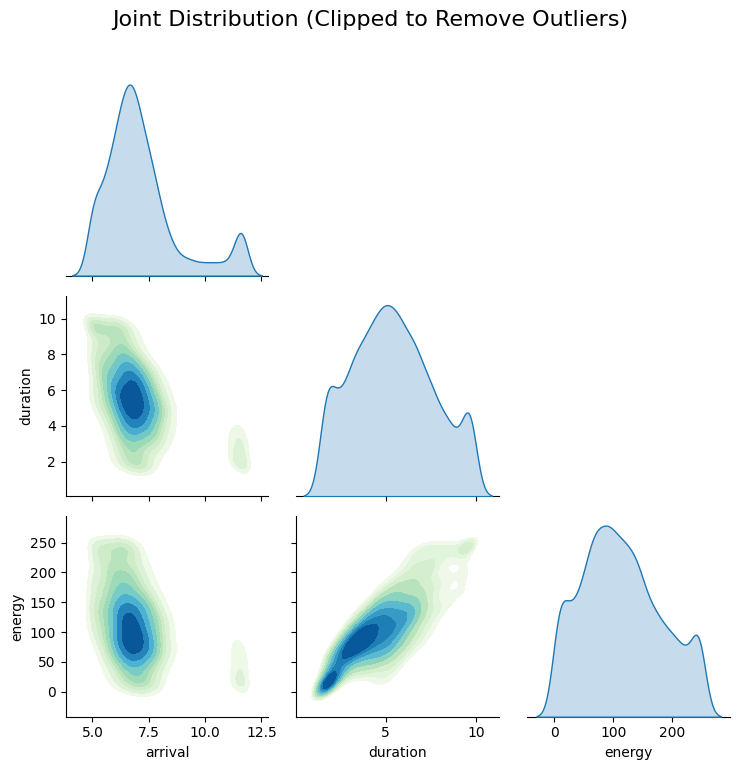

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample_autoregressive(mdn1, mdn2, mdn3, n_samples=1000):
    device = next(mdn1.parameters()).device

    # Step 1: sample x1 ~ p(x1)
    dummy_input = torch.rand(n_samples, 1).to(device)
    pi1, mu1, sigma1 = mdn1(dummy_input)
    x1 = mdn1.sample(pi1, mu1, sigma1)  # shape: (N, 1)

    # Step 2: sample x2 ~ p(x2 | x1)
    pi2, mu2, sigma2 = mdn2(x1)
    x2 = mdn2.sample(pi2, mu2, sigma2)  # shape: (N, 1)

    # Step 3: sample x3 ~ p(x3 | x1, x2)
    x12 = torch.cat([x1, x2], dim=1)
    pi3, mu3, sigma3 = mdn3(x12)
    x3 = mdn3.sample(pi3, mu3, sigma3)  # shape: (N, 1)

    # Final samples (N, 3)
    samples = torch.cat([x1, x2, x3], dim=1).detach().cpu().numpy()
    return samples


# Generate samples
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)

# Convert to DataFrame for seaborn
df_samples = pd.DataFrame(samples, columns=["arrival", "duration", "energy"])

def clip_outliers(df, lower=0.01, upper=0.99):
    return df.apply(lambda x: x.clip(lower=x.quantile(lower), upper=x.quantile(upper)))

df_clipped = clip_outliers(df_samples, lower=0.05, upper=0.95)

# Pairplot (joint distribution visualization)
# sns.pairplot(df_clipped, kind="kde", corner=True, plot_kws={"fill": True, "thresh": 0.05}
             
# sns.set(style="whitegrid")

g = sns.pairplot(
    df_clipped,
    kind="kde",  # use KDE for joint distributions
    diag_kind="kde",  # KDE for the diagonal too
    plot_kws={'cmap': 'GnBu', 'fill': True, 'thresh': 0.2},
    corner=True  # optional: only show lower triangle
)

plt.suptitle("Joint Distribution (Clipped to Remove Outliers)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

def truncate_colormap(cmap_name, minval=0.3, maxval=1.0, n=100):
    cmap = cm.get_cmap(cmap_name)
    new_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap_name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

dark_gnbu = truncate_colormap('GnBu', 0.0, 1.0)


C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_21036\21089964.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


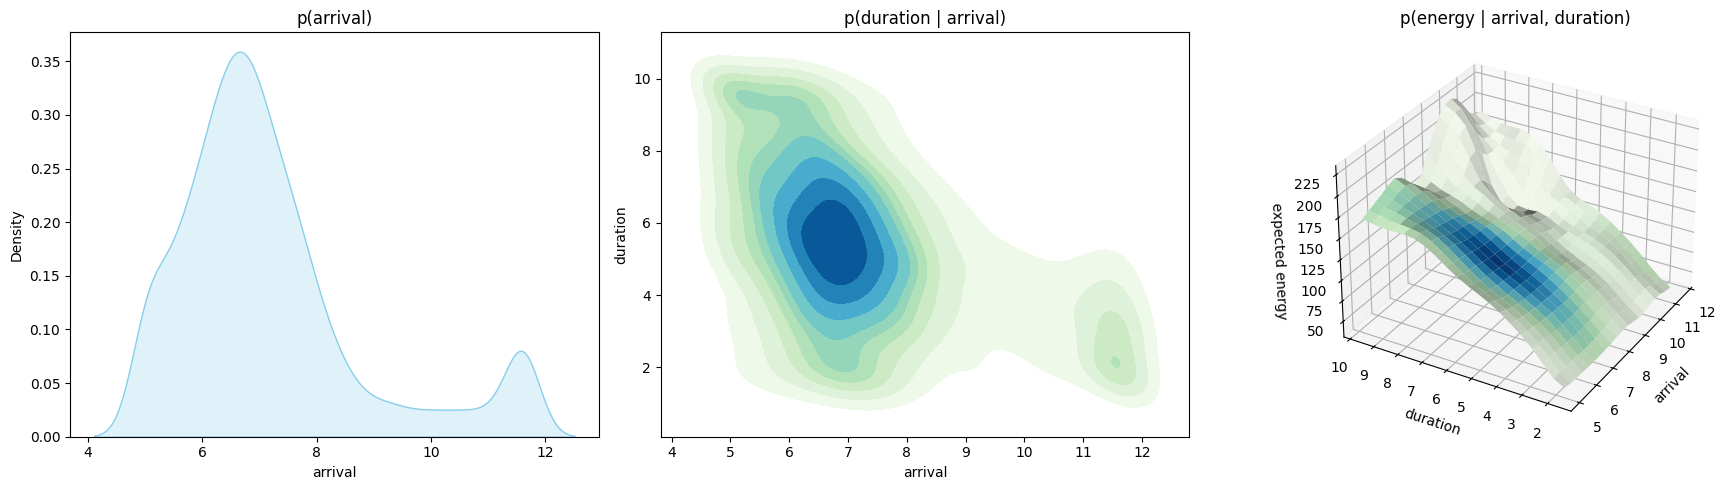

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(18, 5))

# 1D: p(arrival)
ax1 = fig.add_subplot(1, 3, 1)
sns.kdeplot(df_clipped['arrival'], fill=True, color='skyblue', ax=ax1)
ax1.set_title('p(arrival)')


# 2D: p(duration | arrival)
ax2 = fig.add_subplot(1, 3, 2)
sns.kdeplot(
    x=df_clipped['arrival'],
    y=df_clipped['duration'],
    fill=True,
    cmap=dark_gnbu,
    thresh=0.05,
    ax=ax2
)
ax2.set_title('p(duration | arrival)')

'''
# 3D: p(energy | arrival, duration)
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(df_clipped['arrival'], df_clipped['duration'], df_clipped['energy'], c=df_clipped['energy'], cmap=dark_gnbu, s=5)
ax3.set_xlabel('arrival')
ax3.set_ylabel('duration')
ax3.set_zlabel('energy')
ax3.set_title('p(energy | arrival, duration)')
'''

# 3D: p(energy | arrival, duration) with density color
ax4 = fig.add_subplot(1, 3, 3, projection='3d')
# Prepare data for KDE
values = df_clipped[['arrival', 'duration', 'energy']].T.values
kde = gaussian_kde(values)

# Create meshgrid for arrival and duration
x = np.linspace(df_clipped['arrival'].min(), df_clipped['arrival'].max(), 20)
y = np.linspace(df_clipped['duration'].min(), df_clipped['duration'].max(), 20)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)
density_values = np.zeros_like(X)

# Compute expected energy and density
energy_range = np.linspace(df_clipped['energy'].min(), df_clipped['energy'].max(), 100)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Evaluate KDE density over energy range
        density = np.array([kde([X[i, j], Y[i, j], e])[0] for e in energy_range])
        # Compute marginal density p(arrival, duration) by integrating over energy
        density_values[i, j] = np.sum(density) * (energy_range[1] - energy_range[0])
        # Compute expected energy: sum(density * energy) / sum(density)
        if np.sum(density) > 0:
            Z[i, j] = np.sum(density * energy_range) / np.sum(density)
        else:
            Z[i, j] = np.nanmean(df_clipped['energy'])  # Fallback to mean energy

# Normalize density_values for colormap (0 to 1)
density_norm = (density_values - density_values.min()) / (density_values.max() - density_values.min())

# Plot the surface with density color using custom colormap
surf = ax4.plot_surface(X, Y, Z, facecolors=dark_gnbu(density_norm), edgecolor='none', alpha=1)

ax4.set_xlabel('arrival')
ax4.set_ylabel('duration')
ax4.set_zlabel('expected energy')
ax4.set_title('p(energy | arrival, duration)')
# fig.colorbar(surf, shrink=0.5, aspect=10, label='Density')

# Set rotation: elevation (30 degrees) and azimuth (-150 degrees)
ax4.view_init(elev=30, azim=-150)

plt.tight_layout()
plt.show()

In [17]:
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=10)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

# Filter out durations less than 0.5
mask = duration_samples >= 0.5
arrival_samples = arrival_samples[mask]
duration_samples = duration_samples[mask]
energy_samples = energy_samples[mask]

print("Sampled Arrival Times:", arrival_samples)
print("Sampled Durations:", duration_samples)
print("Sampled Energy Consumptions:", energy_samples)

Sampled Arrival Times: [5.620832  7.206657  4.6749167 7.105659  7.724219  7.7474804 6.0705657
 5.190478  6.497346  5.8234215]
Sampled Durations: [5.9409204 3.520679  7.6307    6.1820173 5.427458  6.3325458 6.663868
 6.458086  5.4135327 6.9484916]
Sampled Energy Consumptions: [254.9425   104.72661  258.35626   79.076584 146.34232   42.027184
 151.47221  238.85995  120.24165  159.82254 ]


In [18]:
def sample_duration_given_arrival(mdn2, arrival):
    """Sample duration given a specific arrival time."""
    # sample x2 ~ p(x2 | x1)
    arrival_tensor = torch.tensor(arrival).reshape(-1,1).float()  # shape: (1, 1)
    pi2, mu2, sigma2 = mdn2(arrival_tensor)
    duration_sample = mdn2.sample(pi2, mu2, sigma2)  # shape: (1, 1)
    return duration_sample.item()

sample_duration_given_arrival(mdn2, 9.277739)

4.509196758270264

Sampled Arrival Times: [5.6841326 6.697422  6.232595  7.363405 ]
Sampled Durations: [6.749663  7.108188  5.1492963 6.185422 ]
Sampled Energy Consumptions: [143.18927  239.5966   145.75713   49.985153]


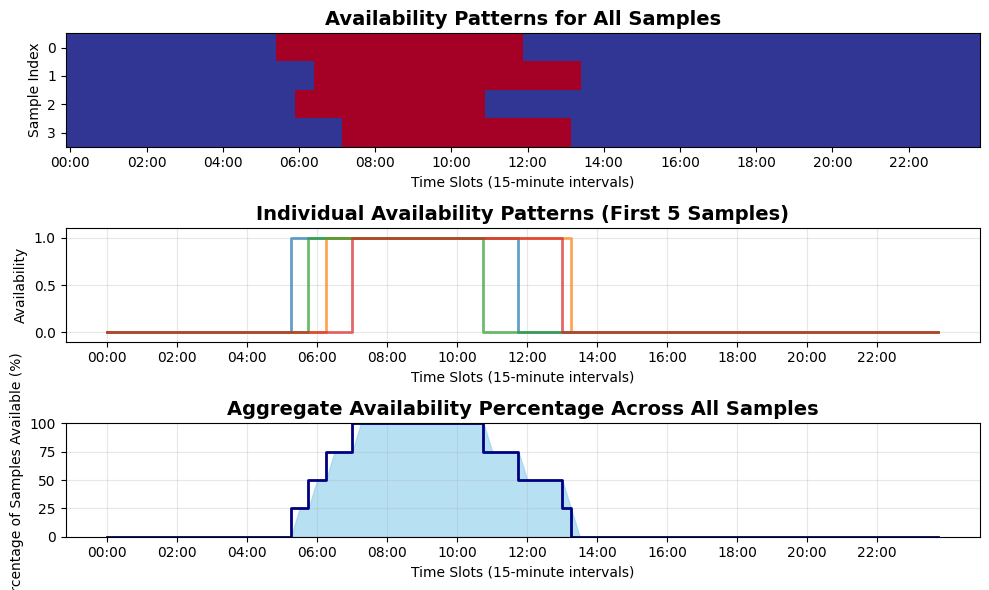


AVAILABILITY SUMMARY
Number of valid samples: 4
Average availability duration: 6.30 hours
Peak availability time: 07:15
Maximum availability percentage: 100.0%
Minimum availability percentage: 0.0%

INDIVIDUAL SAMPLE DETAILS:
--------------------------------------------------------------------------------
Sample   Arrival      Duration     Energy       Departure   
--------------------------------------------------------------------------------
1        05:41        6.75        h 143.19       12:26       
2        06:41        7.11        h 239.60       13:48       
3        06:13        5.15        h 145.76       11:22       
4        07:21        6.19        h 49.99        13:32       


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Your existing code
samples = sample_autoregressive(mdn1, mdn2, mdn3, n_samples=5000)
arrival_samples = samples[:, 0]
duration_samples = samples[:, 1]
energy_samples = samples[:, 2]

# Filter out durations less than 0.5
mask = (0<=arrival_samples) * (5<=duration_samples) * (0<=energy_samples)
arrival_samples = arrival_samples[mask][:4]
duration_samples = duration_samples[mask][:4]
energy_samples = energy_samples[mask][:4]

print("Sampled Arrival Times:", arrival_samples)
print("Sampled Durations:", duration_samples)
print("Sampled Energy Consumptions:", energy_samples)

def compute_availability(arrival_times, durations, n_slots=96):
    """
    Compute availability vectors for multiple samples (vectorized)
    
    Args:
        arrival_times: array of arrival times (in hours, will be converted to 15-min slots)
        durations: array of durations (in hours, will be converted to 15-min slots)
        n_slots: number of time slots (default 96 for 24 hours * 4 intervals)
    
    Returns:
        availability_matrix: shape (n_samples, n_slots)
    """
    n_samples = len(arrival_times)
    
    # Convert hours to 15-minute slots (vectorized)
    arrival_slots = np.clip((arrival_times * 4).astype(int), 0, n_slots - 1)
    duration_slots = (durations * 4).astype(int)
    departure_slots = arrival_slots + duration_slots
    
    # Create time slot indices for broadcasting
    slot_indices = np.arange(n_slots)  # Shape: (n_slots,)
        
    start_mask = slot_indices >= arrival_slots[:, None]  # (n_samples, n_slots)
    
    # Handle normal case (departure within day) and wrap-around case
    normal_case = departure_slots <= n_slots
    end_mask_normal = slot_indices < departure_slots[:, None]  # (n_samples, n_slots)
    end_mask_wraparound = slot_indices < (departure_slots % n_slots)[:, None]  # (n_samples, n_slots)
    
    # Create availability matrix
    availability_matrix = np.zeros((n_samples, n_slots), dtype=int)
    
    # Normal case: within same day
    normal_mask = normal_case[:, None]  # (n_samples, 1)
    availability_matrix = np.where(
        normal_mask,
        start_mask & end_mask_normal,
        start_mask | end_mask_wraparound  # Wrap-around case
    )
    
    return availability_matrix.astype(int)

# Compute availability for all samples
availability_matrix = compute_availability(arrival_samples, duration_samples)

# Create visualizations
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

# 1. Heatmap of all availability patterns
im1 = axes[0].imshow(availability_matrix, cmap='RdYlBu_r', aspect='auto', interpolation='nearest')
axes[0].set_title('Availability Patterns for All Samples', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Slots (15-minute intervals)')
axes[0].set_ylabel('Sample Index')
axes[0].set_xticks(range(0, 96, 8))
axes[0].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
# plt.colorbar(im1, ax=axes[0], label='Available (1) / Not Available (0)')

# 2. Individual availability patterns (first 5 samples)
n_show = min(5, len(arrival_samples))
for i in range(n_show):
    axes[1].plot(availability_matrix[i], alpha=0.7, linewidth=2, drawstyle='steps', 
                label=f'Sample {i+1} (A:{arrival_samples[i]:.1f}h, D:{duration_samples[i]:.1f}h)')

axes[1].set_title('Individual Availability Patterns (First 5 Samples)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Slots (15-minute intervals)')
axes[1].set_ylabel('Availability')
axes[1].set_xticks(range(0, 96, 8))
axes[1].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
# axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

# 3. Aggregate availability (percentage of samples available at each time slot)
aggregate_availability = np.mean(availability_matrix, axis=0) * 100
axes[2].fill_between(range(96), aggregate_availability, alpha=0.6, color='skyblue')
axes[2].plot(aggregate_availability, color='navy', linewidth=2, drawstyle='steps')
axes[2].set_title('Aggregate Availability Percentage Across All Samples', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time Slots (15-minute intervals)')
axes[2].set_ylabel('Percentage of Samples Available (%)')
axes[2].set_xticks(range(0, 96, 8))
axes[2].set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 8)])
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("AVAILABILITY SUMMARY")
print("="*50)
print(f"Number of valid samples: {len(arrival_samples)}")
print(f"Average availability duration: {np.mean(duration_samples):.2f} hours")
print(f"Peak availability time: {np.argmax(aggregate_availability)//4:02d}:{(np.argmax(aggregate_availability)%4)*15:02d}")
print(f"Maximum availability percentage: {np.max(aggregate_availability):.1f}%")
print(f"Minimum availability percentage: {np.min(aggregate_availability):.1f}%")

# Print individual sample details
print("\nINDIVIDUAL SAMPLE DETAILS:")
print("-" * 80)
print(f"{'Sample':<8} {'Arrival':<12} {'Duration':<12} {'Energy':<12} {'Departure':<12}")
print("-" * 80)
for i in range(len(arrival_samples)):
    departure = arrival_samples[i] + duration_samples[i]
    arrival_time = f"{int(arrival_samples[i]):02d}:{int((arrival_samples[i] % 1) * 60):02d}"
    departure_time = f"{int(departure):02d}:{int((departure % 1) * 60):02d}"
    print(f"{i+1:<8} {arrival_time:<12} {duration_samples[i]:<12.2f}h {energy_samples[i]:<12.2f} {departure_time:<12}")

C:\Users\HeydarianArdakaniA\AppData\Local\Temp\ipykernel_21036\517473600.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'$\\mathit{{a}}_{{{i}}}(t)$' for i in range(availability_matrix.shape[0]+1)], size=12)


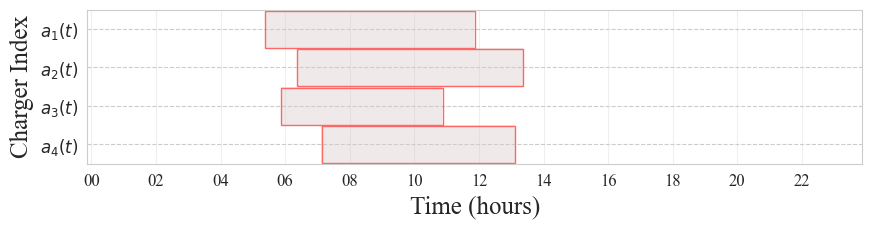

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'

# Create a custom colormap that matches your reference image
# White for 0 (not available), more transparent light pink for 1 (available)
colors = ['white', "#55000016"]  # Added transparency (80 = 50% opacity)
custom_cmap = ListedColormap(colors)

# Create visualizations
fig, ax = plt.subplots(1, 1, figsize=(10, 2))

# 1. Heatmap of all availability patterns
im1 = ax.imshow(availability_matrix, cmap=custom_cmap, aspect='auto', interpolation='nearest')

# Add borders around continuous available periods (whole blocks)
for i in range(availability_matrix.shape[0]):
    j = 0
    while j < availability_matrix.shape[1]:
        if availability_matrix[i, j] == 1:
            # Find the start and end of this continuous block
            start_j = j
            while j < availability_matrix.shape[1] and availability_matrix[i, j] == 1:
                j += 1
            end_j = j - 1
            
            # Draw rectangle around the entire block
            width = end_j - start_j + 1
            rect = plt.Rectangle((start_j-0.5, i-0.475), width, 1*0.96, fill=False, 
                               edgecolor='#ff6666', linewidth=1.0)
            ax.add_patch(rect)
        else:
            j += 1
ax.set_xlabel('Time (hours)', size=18)
ax.set_ylabel('Charger Index', size=18)
ax.set_yticklabels([f'$\\mathit{{a}}_{{{i}}}(t)$' for i in range(availability_matrix.shape[0]+1)], size=12)
ax.set_xticks(range(0, 96, 8))
ax.set_xticklabels([f'{i//4:02d}' for i in range(0, 96, 8)], size=12)
plt.grid(True, axis='x', alpha=0.3)  # Only vertical grid lines
plt.grid(True, axis='y', alpha=1, linestyle='--', linewidth=0.8)  # Only vertical grid lines
plt.savefig('availability.png', dpi=300, bbox_inches='tight', pad_inches=0)

(4,) (97, 4)


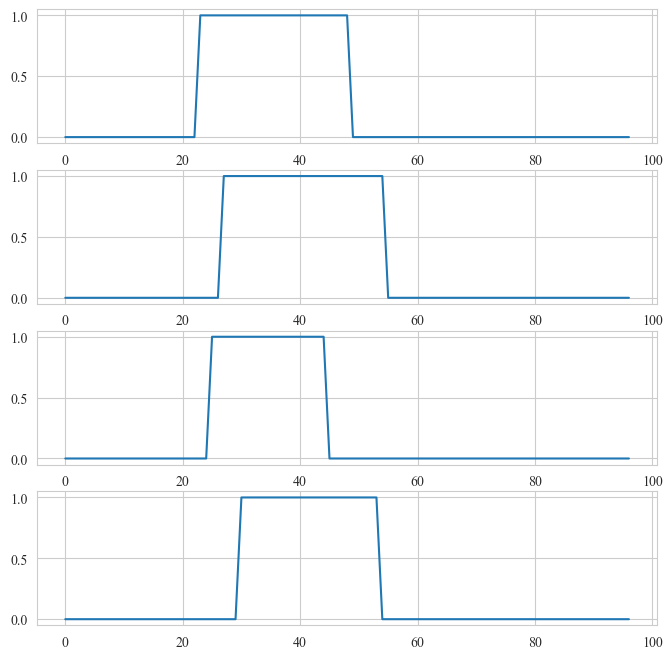

In [21]:
ev_demand_initial_sample = energy_samples/4
charger_availability_data = np.vstack([np.zeros((1, len(availability_matrix))), availability_matrix.T])

print(ev_demand_initial_sample.shape, charger_availability_data.shape)

plt.figure(figsize=(8, 8))
for i in range(len(availability_matrix)):
    plt.subplot(len(availability_matrix),1,i+1)
    plt.plot(charger_availability_data[:,i])

# original one

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Jul 14 01:39:21 PM: Your problem has 1067 variables, 1365 constraints, and 0 parameters.
(CVXPY) Jul 14 01:39:21 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 14 01:39:21 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 14 01:39:21 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 14 01:39:21 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jul 14 01:39:21 PM: Compiling problem (target solver=SCIP).

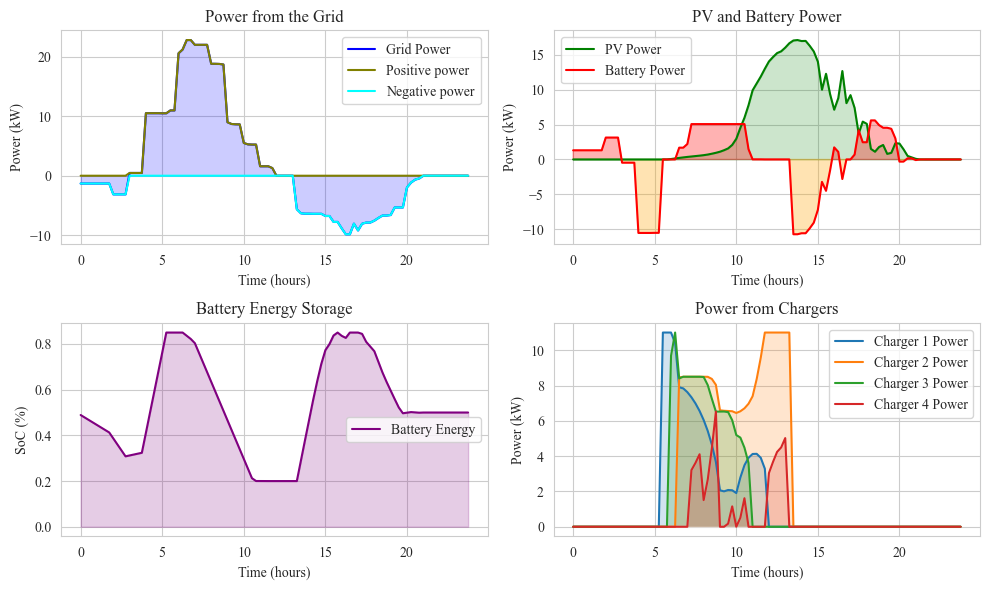

In [23]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = expanded_pv[:num_time_steps+1]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = charger_availability_data  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = ev_demand_initial_sample.ravel()  # Demand for each EV (size: num_chargers)
price = expanded_price[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.85
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage = cp.Variable(num_time_steps+1)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage <= charge_discharge_limit)
constraints.append(p_storage >= -charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] - p_storage[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2)+
    cp.sum(cp.multiply(price, p_grid_positive)) -
    cp.sum(cp.multiply(price/2, p_grid_negative)) +
    cp.sum(slack ** 2) * 1e3 +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage.value[1:], label='Battery Power', color='red')
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()

# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


# written optimizaiton

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Jul 14 01:51:53 PM: Your problem has 1164 variables, 1462 constraints, and 0 parameters.
(CVXPY) Jul 14 01:51:53 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 14 01:51:53 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 14 01:51:53 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 14 01:51:53 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jul 14 01:51:53 PM: Compiling problem (target solver=SCIP).

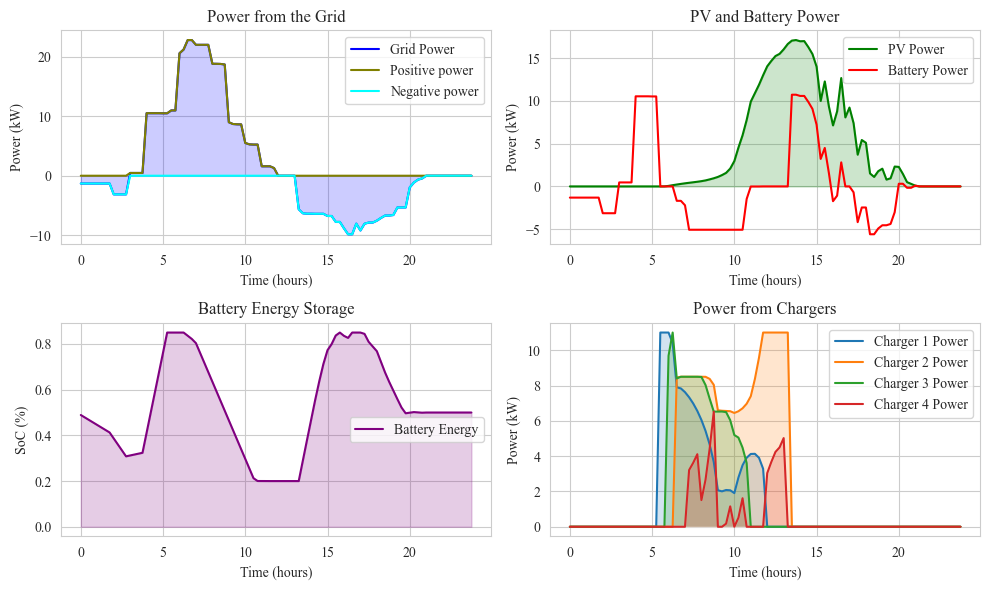

In [38]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = expanded_pv[:num_time_steps+1]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = charger_availability_data  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = ev_demand_initial_sample.ravel()  # Demand for each EV (size: num_chargers)
price = expanded_price[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.85
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage_ch = cp.Variable(num_time_steps+1, nonneg=True)
p_storage_dis = cp.Variable(num_time_steps+1, nonneg=True)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)
zeta_storage = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage_dis - p_storage_ch == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
# constraints.append(p_storage_ch-p_storage_dis <= charge_discharge_limit)
# constraints.append(p_storage_dis-p_storage_ch <= charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] + p_storage_ch[1:] * time_resolution - p_storage_dis[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(zeta_storage <= 1)
constraints.append(p_storage_ch <= zeta_storage * p_charger_limit)
constraints.append(p_storage_dis <= (1-zeta_storage) * p_charger_limit)


# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage_ch) + cp.tv(p_storage_dis) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2)+
    cp.sum(cp.multiply(price, p_grid_positive)) -
    cp.sum(cp.multiply(price/2, p_grid_negative)) +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage_ch.value[1:]-p_storage_dis.value[1:], label='Battery Power', color='red')
# plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
# plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()


# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


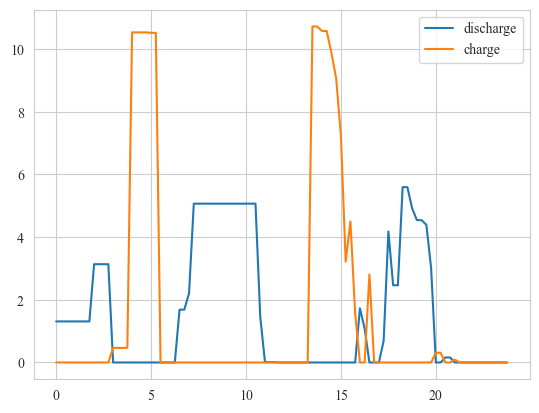

In [39]:
plt.plot(time_steps, p_storage_dis.value[1:], label='discharge')
plt.plot(time_steps, p_storage_ch.value[1:], label='charge')
plt.legend()

# second modified optimizaiton

                                     CVXPY                                     
                                     v1.5.2                                    
(CVXPY) Jul 14 01:51:57 PM: Your problem has 1067 variables, 1365 constraints, and 0 parameters.
(CVXPY) Jul 14 01:51:57 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 14 01:51:57 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 14 01:51:57 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 14 01:51:57 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Jul 14 01:51:57 PM: Compiling problem (target solver=SCIP).

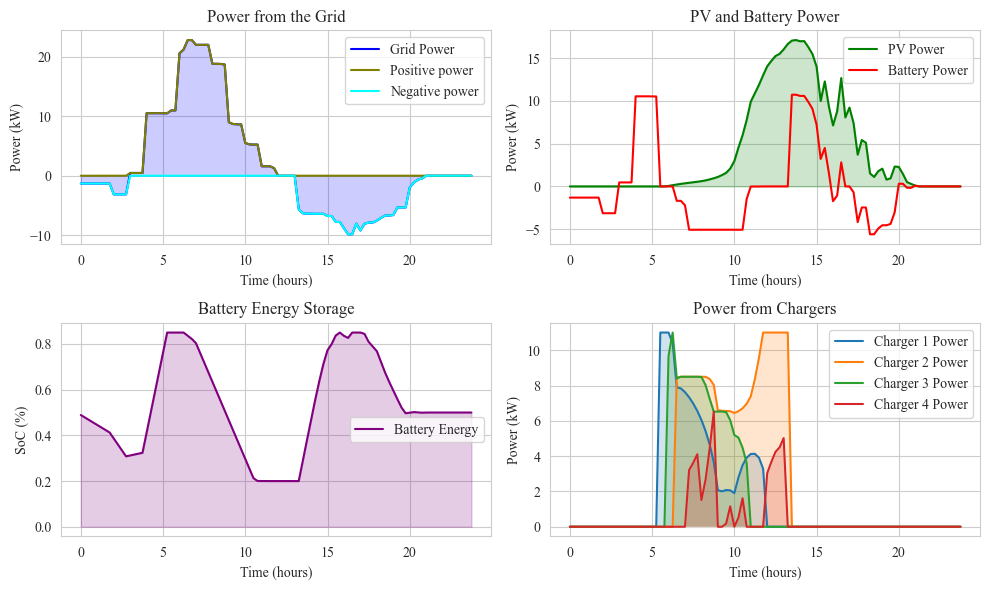

In [40]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# Parameters
num_time_steps = 24*4  # 24 hours * 4 (15-minute resolution)
num_chargers = 4

p_pv = expanded_pv[:num_time_steps+1]/ 1000  # PV power generation over time (size: num_time_steps)
charger_availability = charger_availability_data  # Charger availability (size: num_chargers x num_time_steps)
ev_demand = ev_demand_initial_sample.ravel()  # Demand for each EV (size: num_chargers)
price = expanded_price[:num_time_steps+1]

time_resolution = 0.25  # 15 minutes

# Storage constraints
storage_capacity = 30  # Example capacity
capacity_high_limit = 0.85
capacity_low_limit = 0.2

charge_discharge_limit = 14  # Example charge/discharge limit
p_charger_limit = 11

# Decision Variables
p_chargers = cp.Variable((num_time_steps+1, num_chargers), nonneg=True)
p_grid = cp.Variable(num_time_steps+1)
p_grid_positive = cp.Variable(num_time_steps+1, nonneg=True)
p_grid_negative = cp.Variable(num_time_steps+1, nonneg=True)
p_storage_ch = cp.Variable(num_time_steps+1, nonneg=True)
p_storage_dis = cp.Variable(num_time_steps+1, nonneg=True)
storage_energy = cp.Variable(num_time_steps+1, nonneg=True)

# Binary variables for big-M method
binary_pos = cp.Variable(num_time_steps+1, boolean=True)

# Big-M constant
M = 1e5

# Constraints
constraints = []

# Charger availability constraints
constraints.append(p_chargers <= charger_availability * p_charger_limit)

# Power balance constraints
constraints.append(p_pv + p_grid + p_storage_dis - p_storage_ch == cp.sum(p_chargers, axis=1))

constraints.append(storage_energy <= storage_capacity * capacity_high_limit)
constraints.append(storage_energy >= storage_capacity * capacity_low_limit)
constraints.append(p_storage_ch-p_storage_dis <= charge_discharge_limit)
constraints.append(p_storage_dis-p_storage_ch <= charge_discharge_limit)
constraints.append(storage_energy[0] == storage_capacity / 2)  # Initial storage level
constraints.append(storage_energy[-1] == storage_capacity / 2)

constraints.append(storage_energy[1:] == storage_energy[:-1] + p_storage_ch[1:] * time_resolution - p_storage_dis[1:] * time_resolution)

# Initial conditions
# constraints.append(self.p_grid[0] == self.p_grid_initial)
constraints.append(p_grid_positive[0] == 0)
constraints.append(p_grid_negative[0] == 0)

# EV demand constraints
constraints.append(cp.sum(p_chargers * time_resolution, axis=0) >= ev_demand)

# Auxiliary variables constraints
constraints.append(p_grid == p_grid_positive - p_grid_negative)

# Ensure p_grid_positive and p_grid_negative cannot be positive at the same time
constraints.append(binary_pos <= 1)
constraints.append(p_grid_positive <= binary_pos * M)
constraints.append(p_grid_negative <= (1-binary_pos) * M)

# Smoothing constraint to avoid abrupt changes
smoothing_penalty = cp.tv(p_grid_positive) + cp.tv(p_grid_negative) + cp.tv(p_storage_ch) + cp.tv(p_storage_dis) + 2*cp.tv(p_chargers) 

# Objective: Minimize total grid power usage, slack, and smoothing
objective = cp.Minimize(
    cp.sum(p_grid ** 2)+
    cp.sum(cp.multiply(price, p_grid_positive)) -
    cp.sum(cp.multiply(price/2, p_grid_negative)) +
    smoothing_penalty
)

# Problem definition and solving
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCIP, verbose=True)

# Output the results
print("Problem status:", problem.status)
if problem.status not in ["infeasible", "unbounded"]:
    print("Optimal objective value:", objective.value)
else:
    print("The problem is infeasible or unbounded.")

plt.figure(figsize=(10, 6))
time_steps = np.arange(len(p_grid.value[1:])) / 4  # Scale the time steps to hours

# Plot grid power
plt.subplot(2, 2, 1)
plt.plot(time_steps, p_grid.value[1:], label='Grid Power', color='blue')
plt.fill_between(time_steps, 0, p_grid.value[1:], color='blue', alpha=0.2)
plt.plot(time_steps, p_grid_positive.value[1:], label='Positive power', color='olive')
plt.plot(time_steps, -p_grid_negative.value[1:], label='Negative power', color='cyan')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from the Grid')
plt.legend()

# Plot PV power and battery power
plt.subplot(2, 2, 2)
plt.plot(time_steps, p_pv[1:], label='PV Power', color='green')
plt.fill_between(time_steps, 0, p_pv[1:], color='green', alpha=0.2)
plt.plot(time_steps, p_storage_ch.value[1:]-p_storage_dis.value[1:], label='Battery Power', color='red')
# plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) >= 0, color='red', alpha=0.3, interpolate=True)
# plt.fill_between(time_steps, 0, p_storage.value[1:], where=np.array(p_storage.value[1:]) < 0, color='orange', alpha=0.3, interpolate=True)
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV and Battery Power')
plt.legend()


# Plot battery energy
plt.subplot(2, 2, 3)
plt.plot(time_steps, np.array(storage_energy.value[1:]) / storage_capacity, label='Battery Energy', color='purple')
plt.fill_between(time_steps, 0, np.array(storage_energy.value[1:]) / storage_capacity, color='purple', alpha=0.2)
plt.xlabel('Time (hours)')
plt.ylabel('SoC (%)')
plt.title('Battery Energy Storage')
plt.legend()

# Plot charger power
plt.subplot(2, 2, 4)
for i in range(4):
    plt.plot(time_steps, p_chargers.value[1:, i], label=f'Charger {i + 1} Power')
    plt.fill_between(time_steps, 0, p_chargers.value[1:, i], alpha=0.2)

plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Power from Chargers')
plt.legend()

plt.tight_layout()
plt.show()


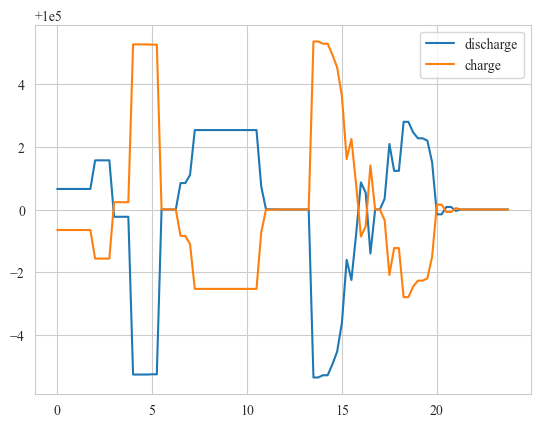

In [41]:
plt.plot(time_steps, p_storage_dis.value[1:], label='discharge')
plt.plot(time_steps, p_storage_ch.value[1:], label='charge')
plt.legend()